## 1. Load tesla_deliveries_dataset_2015_2025.csv into a DataFrame. Print shape, columns, .info(), and .describe().

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv('/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv')

In [2]:
df = df.sort_values(['Year', 'Month']).reset_index(drop=True)

print(f'Shape:\n{df.shape}\n\n')
print(f'Columns:\n{df.columns}\n\n')
print(f'Information:\n{df.info()}\n\n')
print(f'Describe:\n{df.describe(include='all')}\n')

Shape:
(2640, 12)


Columns:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type   

The Tesla deliveries dataset was successfully loaded into a Pandas DataFrame. The shape of the dataset provided information about the total number of observations and features available for analysis.
The column names revealed the variables present in the dataset, such as production units, estimated deliveries, battery specifications, and regional information.
The `.info()` function was used to understand the data types of each column and identify any missing values.
The `.describe()` function generated summary statistics for numerical features, including measures such as mean, standard deviation, minimum, maximum, and quartiles. This initial exploration helped in understanding the structure and characteristics of the dataset before proceeding with further analysis.


## 2. Check for missing values and duplicate rows.

In [3]:
print(f"Missing values\n")
print(df.isnull().sum())
print(f'\nDuplicates:\n')
print(df.duplicated().sum())

Missing values

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicates:

0


The dataset was checked for missing values and duplicate records to ensure data quality. The absence of missing values and duplicates indicates that the dataset is clean and suitable for further analysis.


## 3. Create 5 EDA charts: deliveries by Model, by Region, correlation heatmap, Production vs Deliveries scatter, and time-trend line. All charts need titles and axis labels.

In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2015,1,Middle East,Model Y,10348,10835,85599.95,82,488,757.47,Estimated (Region),5991
1,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390
2,2015,1,Europe,Model Y,10835,11723,62939.81,120,718,1166.93,Official (Quarter),12301
3,2015,1,North America,Model X,8122,8343,62838.32,75,423,515.34,Official (Quarter),9297
4,2015,1,Middle East,Model S,13902,15423,94629.02,75,445,927.96,Official (Quarter),8666


### Total Deliveries by Tesla Model

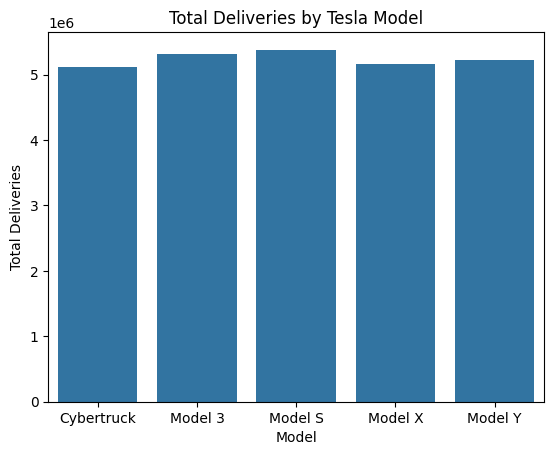

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum().reset_index()

sns.barplot(data=model_deliveries,x='Model',y='Estimated_Deliveries')

plt.title('Total Deliveries by Tesla Model')
plt.xlabel('Model')
plt.ylabel('Total Deliveries')
plt.show()

In [6]:
model_deliveries

,Model,Estimated_Deliveries
0,Cybertruck,5109779
1,Model 3,5321919
2,Model S,5380385
3,Model X,5157240
4,Model Y,5225284


This bar chart illustrates the total estimated deliveries for each Tesla model. It helps identify which models contributed the most to Tesla's overall deliveries. Model S was delivered the most.

### Total Deliveries by Region

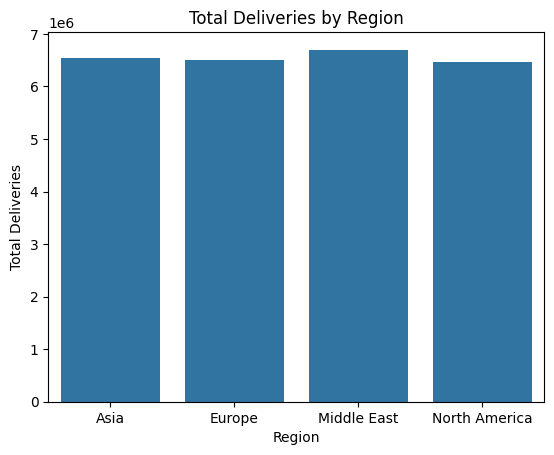

In [7]:
model_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum().reset_index()

sns.barplot(data=model_deliveries,x='Region',y='Estimated_Deliveries')
plt.title('Total Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Total Deliveries')
plt.show()


The regional deliveries chart compares the total estimated deliveries across different geographical regions. This visualization highlights the regions where Tesla vehicles have achieved greater market penetration and customer adoption. Middle East had the most deliveries.

### Correlation Heatmap

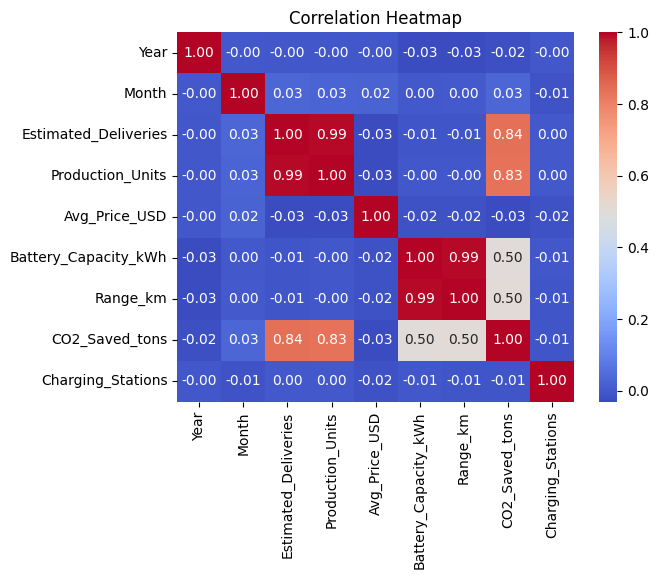

In [8]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap displays the strength and direction of linear relationships between numerical variables. The analysis revealed that Production_Units had an extremely strong positive correlation with Estimated_Deliveries, suggesting that production volume is a key determinant of deliveries. Additionally, CO2_Saved_tons exhibited a relatively high correlation with estimated deliveries.

### Production vs Deliveries

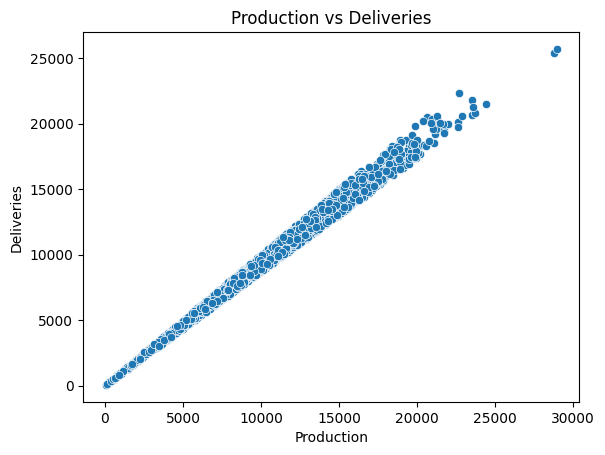

In [9]:
sns.scatterplot(data=df,x='Production_Units',y='Estimated_Deliveries')

plt.title('Production vs Deliveries')
plt.xlabel('Production')
plt.ylabel('Deliveries')
plt.show()

The scatter plot visualizes the relationship between production units and estimated deliveries. The upward trend observed in the plot suggests that higher production levels are associated with greater deliveries. This finding supports the strong correlation observed in the heatmap.

### Tesla Deliveries Trend

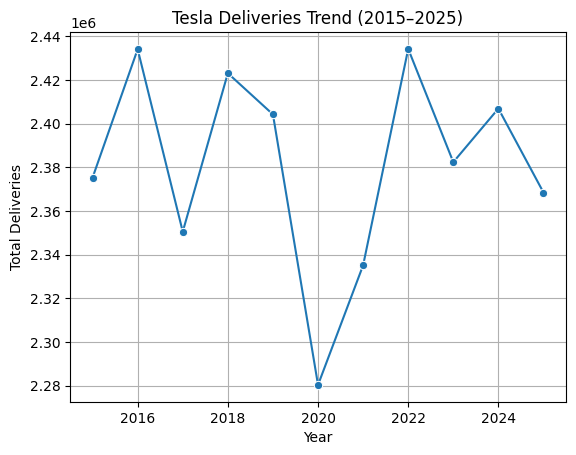

In [10]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

sns.lineplot(x=yearly_deliveries.index,y=yearly_deliveries.values,marker='o')

plt.title('Tesla Deliveries Trend (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Total Deliveries')
plt.grid(True)
plt.show()

The line chart presents the yearly trend in Tesla's estimated deliveries from 2015 to 2025. This visualization helps identify growth patterns, fluctuations, or long-term trends in deliveries over the study period. Year 2020 had a significant dop in total deliveries, the most common cause can be the Covid 19 pandemic.

## 4. Encode Region, Model, Source_Type using LabelEncoder. Create Deliveries_Lag1 (shift by 1, fill NaN with mean) and Rolling_Mean_3 (3-period rolling mean, fill NaN with mean).

### Label encoded Region, Model, Source_Type

In [11]:
from sklearn.preprocessing import LabelEncoder

# Create a copy (optional)
df_encoded = df.copy()

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df_encoded['Region'] = le_region.fit_transform(df_encoded['Region'])
df_encoded['Model'] = le_model.fit_transform(df_encoded['Model'])
df_encoded['Source_Type'] = le_source.fit_transform(df_encoded['Source_Type'])


### Created Deliveries_Lag1

In [12]:
df_encoded['Deliveries_Lag1'] = df_encoded['Estimated_Deliveries'].shift(1)

# Fill NaN with mean
lag_mean = df_encoded['Deliveries_Lag1'].mean()
df_encoded['Deliveries_Lag1'].fillna(lag_mean, inplace=True)

/tmp/ipykernel_16/714517504.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded['Deliveries_Lag1'].fillna(lag_mean, inplace=True)


### Created Rolling_Mean_3

In [13]:
df_encoded['Rolling_Mean_3'] = (df_encoded['Estimated_Deliveries'].rolling(window=3).mean())

# Fill NaN with mean
rolling_mean = df_encoded['Rolling_Mean_3'].mean()
df_encoded['Rolling_Mean_3'].fillna(rolling_mean, inplace=True)

/tmp/ipykernel_16/1814058249.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_encoded['Rolling_Mean_3'].fillna(rolling_mean, inplace=True)


In [14]:
df_encoded

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Deliveries_Lag1,Rolling_Mean_3
0,2015,1,2,4,10348,10835,85599.95,82,488,757.47,0,5991,9921.649488,9921.864797
1,2015,1,0,4,12446,13885,55183.13,60,340,634.75,2,4390,10348.000000,9921.864797
2,2015,1,1,4,10835,11723,62939.81,120,718,1166.93,2,12301,12446.000000,11209.666667
3,2015,1,3,3,8122,8343,62838.32,75,423,515.34,2,9297,10835.000000,10467.666667
4,2015,1,2,2,13902,15423,94629.02,75,445,927.96,2,8666,8122.000000,10953.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2025,12,3,2,9880,11062,58904.29,120,683,1012.21,1,6257,12747.000000,10597.000000
2636,2025,12,2,1,11157,12278,50941.08,82,459,768.16,1,11194,9880.000000,11261.333333
2637,2025,12,0,3,13671,15308,67998.03,60,348,713.63,0,8520,11157.000000,11569.333333
2638,2025,12,3,3,6293,6849,67797.67,82,461,435.16,0,8860,13671.000000,10373.666667


Categorical variables such as Region, Model, and Source_Type were transformed into numerical representations using Label Encoding to make them suitable for machine learning algorithms. Furthermore, two time-based features were engineered: Deliveries_Lag1, representing the previous period's deliveries, and Rolling_Mean_3, representing the three-period moving average of deliveries. These features capture temporal dependencies and short-term trends in delivery patterns, potentially improving predictive performance.

## 5. Split data chronologically 80/20 using index slicing — NOT train_test_split. Train Linear Regression, print MAE, RMSE, R², and plot Actual vs Predicted.

In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = df_encoded.drop('Estimated_Deliveries', axis=1)
y = df_encoded['Estimated_Deliveries']

split_index = int(len(df_encoded) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

### Train linear regression

In [16]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

### Evaluation

In [17]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMS: {rmse:.2f}")
print(f"R² : {r2:.4f}")

MAE: 317.93
RMS: 386.69
R² : 0.9889


The dataset was divided chronologically into training and testing sets using an 80:20 split to preserve temporal order. A Linear Regression model was trained to predict estimated deliveries.

Model performance was evaluated using:

Mean Absolute Error (MAE): Measures the average absolute difference between actual and predicted values.
Root Mean Squared Error (RMSE): Measures the magnitude of prediction errors while penalizing larger errors more heavily.
R² Score: Represents the proportion of variance in the target variable explained by the model.

Higher R² values and lower MAE and RMSE values indicate better predictive performance.

### Actual vs Predicted Plot

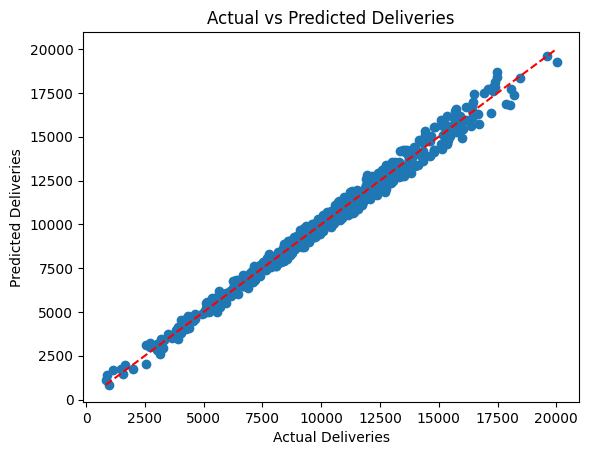

In [18]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')

plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted Deliveries')

plt.show()

The scatter plot comparing actual and predicted deliveries assesses how closely the model's predictions align with true values.

## 6. Run 5-Fold Cross Validation on Linear Regression. Print per-fold R² and mean.

In [19]:
from sklearn.model_selection import KFold, cross_val_score
kf = KFold(n_splits=5, shuffle=False)

r2_scores = cross_val_score(lr, X, y,cv=kf,scoring='r2')

# Print R² for each fold
for i, score in enumerate(r2_scores, start=1):
    print(f"Fold {i} R²: {score:.4f}")

# Print mean R²
print(f"\nMean R²: {np.mean(r2_scores):.4f}")

Fold 1 R²: 0.9901
Fold 2 R²: 0.9911
Fold 3 R²: 0.9909
Fold 4 R²: 0.9906
Fold 5 R²: 0.9889

Mean R²: 0.9903


Five-fold cross validation was performed to evaluate the robustness and generalization capability of the Linear Regression model. The dataset was divided into five subsets, with the model being trained on four subsets and validated on the remaining subset in each iteration. The R² score for each fold was recorded, and the mean R² score was computed. Consistent R² scores across folds indicate that the model performs reliably on unseen data and is not overly dependent on a particular train-test split.

## 7. Run GridSearchCV on RandomForestRegressor with n_estimators=[50,100], max_depth=[5,10,None]. Train best model, evaluate, and plot top 10 feature importances.


In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
param_grid = {'n_estimators': [50, 100],'max_depth': [5, 10, None]}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation R²:", grid_search.best_score_)

y_pred = best_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nTest Set Performance:")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Best Parameters: {'max_depth': None, 'n_estimators': 50}
Best Cross-Validation R²: 0.9885257041542381

Test Set Performance:
MAE  : 335.46
RMSE : 415.06
R²   : 0.9872


              Feature  Importance
4    Production_Units    0.990529
8      CO2_Saved_tons    0.001942
12     Rolling_Mean_3    0.001178
7            Range_km    0.001103
5       Avg_Price_USD    0.001053
11    Deliveries_Lag1    0.000946
10  Charging_Stations    0.000885
1               Month    0.000670
0                Year    0.000565
3               Model    0.000419


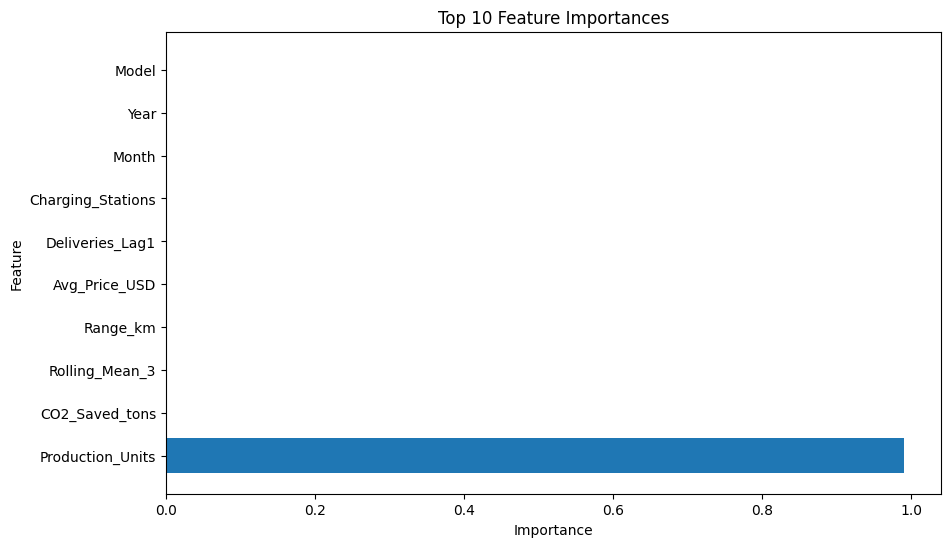

In [21]:
feature_importances = pd.DataFrame({'Feature': X.columns,'Importance': best_rf.feature_importances_})

feature_importances = (feature_importances.sort_values(by='Importance', ascending=False).head(10))
print(feature_importances)
plt.figure(figsize=(10, 6))

plt.barh(feature_importances['Feature'],feature_importances['Importance'])

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')

plt.show()

A Random Forest Regressor was optimized using GridSearchCV to identify the best combination of hyperparameters. The parameters explored included the number of trees (n_estimators) and maximum tree depth (max_depth).

The optimized model was evaluated using MAE, RMSE, and R² metrics. Feature importance analysis was subsequently performed to determine which variables contributed most significantly to delivery predictions.

The results showed that Production_Units was the most influential predictor of estimated deliveries. This finding is consistent with the correlation analysis, which demonstrated a very strong positive relationship between production and deliveries. Although variables such as CO2_Saved_tons were also highly correlated with estimated deliveries, their contribution to the Random Forest model was limited because the predictive information they contained largely overlapped with that provided by Production_Units.

## 8. Run ADF stationarity test on Estimated_Deliveries. Interpret the p-value.

In [22]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Estimated_Deliveries'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Number of lags used:", result[2])
print("Number of observations:", result[3])
if result[1] < 0.05:
    print("Reject H₀: The series is stationary.")
else:
    print("Fail to reject H₀: The series is non-stationary.")

ADF Statistic: -24.662112249181465
p-value: 0.0
Number of lags used: 4
Number of observations: 2635
Reject H₀: The series is stationary.


The Augmented Dickey-Fuller (ADF) test was conducted to determine whether the Estimated_Deliveries time series was stationary.

The null hypothesis (H₀) states that the series is non-stationary, while the alternative hypothesis (H₁) states that the series is stationary.

The obtained ADF statistic was -24.6621 with a p-value of 0.0000. Since the p-value is less than the significance threshold of 0.05, the null hypothesis was rejected. Therefore, it was concluded that the Estimated_Deliveries series is stationary. This indicates that the statistical properties of the series, such as mean and variance, remain relatively stable over time.

## 9. Build a forecast table comparing actual vs predicted for first 20 test records with error %.

In [23]:
forecast_df = pd.DataFrame({'Actual': y_test.values[:20],'Predicted': y_pred[:20]})

# Calculate Error
forecast_df['Error'] = (forecast_df['Actual']- forecast_df['Predicted'])

# Calculate Error Percentage
forecast_df['Error_%'] = (abs(forecast_df['Error'])/ forecast_df['Actual']) * 100

print(forecast_df)

    Actual  Predicted   Error   Error_%
0     9476    8955.58  520.42  5.491980
1     8179    8441.62 -262.62  3.210906
2    14430   15350.52 -920.52  6.379210
3    15912   15872.28   39.72  0.249623
4    15077   14687.56  389.44  2.583007
5    11280   11322.78  -42.78  0.379255
6     4070    4116.68  -46.68  1.146929
7    11636   11555.88   80.12  0.688553
8    12540   12241.86  298.14  2.377512
9    12717   11734.44  982.56  7.726351
10    5365    5743.98 -378.98  7.063933
11   11323   11842.92 -519.92  4.591716
12    8624    8944.98 -320.98  3.721939
13   11986   11690.66  295.34  2.464041
14   10577   11122.36 -545.36  5.156093
15   15370   15239.08  130.92  0.851789
16    2737    2867.08 -130.08  4.752649
17   11523   11669.40 -146.40  1.270502
18   10530   10341.18  188.82  1.793162
19   11111   10690.96  420.04  3.780398


A forecast table was created to compare the actual and predicted delivery values for the first 20 observations in the test dataset. The table included the prediction error and percentage error for each observation.

The error percentage provides insight into the relative magnitude of prediction errors. Smaller error percentages indicate more accurate predictions, whereas larger values suggest areas where the model struggled to capture underlying patterns.

# Conclusion

This analysis explored Tesla delivery patterns using exploratory data analysis, feature engineering, statistical testing, and machine learning techniques. The findings highlighted a strong relationship between production units and estimated deliveries, emphasizing the importance of production capacity in forecasting deliveries. Linear Regression and Random Forest models were developed and evaluated, with the Random Forest model benefiting from hyperparameter tuning through GridSearchCV. Stationarity analysis confirmed that the delivery series was stable over time. Overall, the study demonstrated the application of data analytics and predictive modeling techniques to understand and forecast Tesla delivery trends effectively.
